<a href="https://colab.research.google.com/github/polxo00/Algoritmos-de-optimizacion/blob/main/Recocido_simulado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

# definición de la funcion objetivo
def func(x):
    return x**2 + 10 * math.sin(x)

# Slución vecina
def new_solution(x):
    return x + random.uniform(-1, 1)

# Recocido simulado
def simulated_annealing(initial_temp, cooling_rate, max_iter):
    #x = random.uniform(-10, 10)
    x = 9
    best = x
    T = initial_temp
    history = [(x, func(x))]

    for i in range(max_iter):
        x_new = new_solution(x)
        delta = func(x_new) - func(x)

        if delta < 0 or random.uniform(0, 1) < math.exp(-delta / T):
            x = x_new
            if func(x) < func(best):
                best = x

        T *= cooling_rate
        history.append((x, func(x)))

    return best, func(best), history


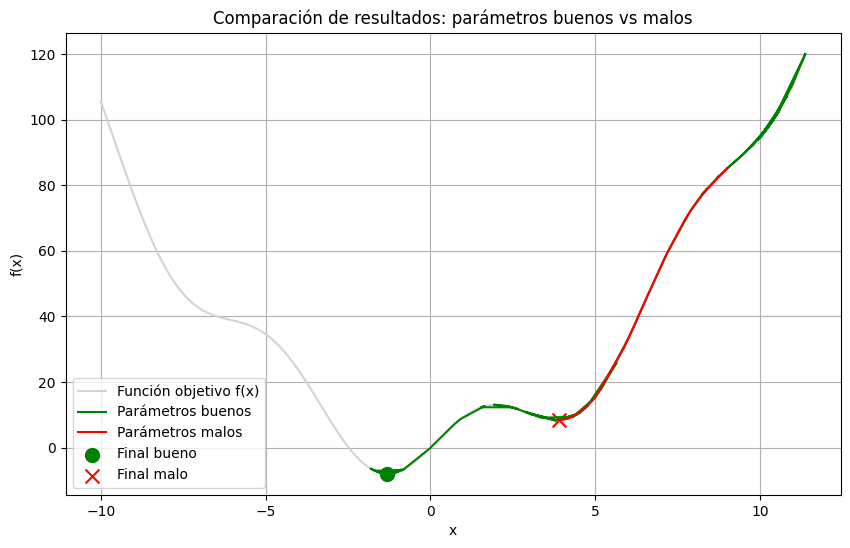

In [15]:

# Ejecutamos con diferentes parametros
best_good, val_good, hist_good = simulated_annealing(100, 0.95, 300)
best_bad, val_bad, hist_bad = simulated_annealing(10, 0.5, 50)

# Graficoamos los resultados
x_vals = np.linspace(-10, 10, 500)
y_vals = [func(x) for x in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Función objetivo f(x)', color='lightgray')

plt.plot([x for x, _ in hist_good], [y for _, y in hist_good], label='Parámetros buenos', color='green')
plt.plot([x for x, _ in hist_bad], [y for _, y in hist_bad], label='Parámetros malos', color='red')

plt.scatter([best_good], [val_good], color='green', marker='o', s=100, label='Final bueno')
plt.scatter([best_bad], [val_bad], color='red', marker='x', s=100, label='Final malo')

plt.title("Comparación de resultados: parámetros buenos vs malos")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()
